# Project 2: Predicting Whether a Person Has Heart Disease or Not Using Logistic Regression
The objective of this project is to build, evaluate, and interpret Logistic Regression using heart disease Dataset. We will handle data cleaning, feature engineering, and verify regression assumptions.

## Authors
### 1- Yousuf Islam Mohammad - 231006958
### 2- Abdulrehman Hatem Hassan - 231006575

## 0. Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, roc_curve, auc
from sklearn.impute import KNNImputer
from sklearn.preprocessing import StandardScaler
import warnings 
## Ignore warnings for cleaner output
warnings.filterwarnings('ignore')

## 1. Initial Data Exploration (EDA)

In [2]:
# Load and copy the heart disease dataset
df_hd = pd.read_csv('heart_disease_uci.csv')
df_hd_copy = df_hd.copy()

In [3]:
df_hd_copy.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [4]:
df_hd_copy.describe()

,id,age,trestbps,chol,thalch,oldpeak,ca,num
count,920.000000,920.000000,861.000000,890.000000,865.000000,858.000000,309.000000,920.000000
mean,460.500000,53.510870,132.132404,199.130337,137.545665,0.878788,0.676375,0.995652
std,265.725422,9.424685,19.066070,110.780810,25.926276,1.091226,0.935653,1.142693
min,1.000000,28.000000,0.000000,0.000000,60.000000,-2.600000,0.000000,0.000000
25%,230.750000,47.000000,120.000000,175.000000,120.000000,0.000000,0.000000,0.000000
50%,460.500000,54.000000,130.000000,223.000000,140.000000,0.500000,0.000000,1.000000
75%,690.250000,60.000000,140.000000,268.000000,157.000000,1.500000,1.000000,2.000000
max,920.000000,77.000000,200.000000,603.000000,202.000000,6.200000,3.000000,4.000000


In [5]:
df_hd_copy.info()

<class 'pandas.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    str    
 3   dataset   920 non-null    str    
 4   cp        920 non-null    str    
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    str    
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    str    
 13  ca        309 non-null    float64
 14  thal      434 non-null    str    
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(2), str(6)
memory usage: 115.1+ KB


In [6]:
# Statistical summary for categorical columns
print("\n--- Categorical Description ---")
display(df_hd_copy.describe(include=['O']))# 'O' stands for object, which is typically used for categorical data in pandas


--- Categorical Description ---


,sex,dataset,cp,fbs,restecg,exang,slope,thal
count,920,920,920,830,918,865,611,434
unique,2,4,4,2,3,2,3,3
top,Male,Cleveland,asymptomatic,False,normal,False,flat,normal
freq,726,304,496,692,551,528,345,196


In [7]:
# Check for missing values in the heart disease dataset
print("Missing values in heart disease dataset:")
print(df_hd_copy.isnull().sum())

Missing values in heart disease dataset:
id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64


In [8]:
# Check for duplicate rows in the heart disease dataset
print("Duplicate rows in heart disease dataset:")
print(df_hd_copy.duplicated().sum())

Duplicate rows in heart disease dataset:
0


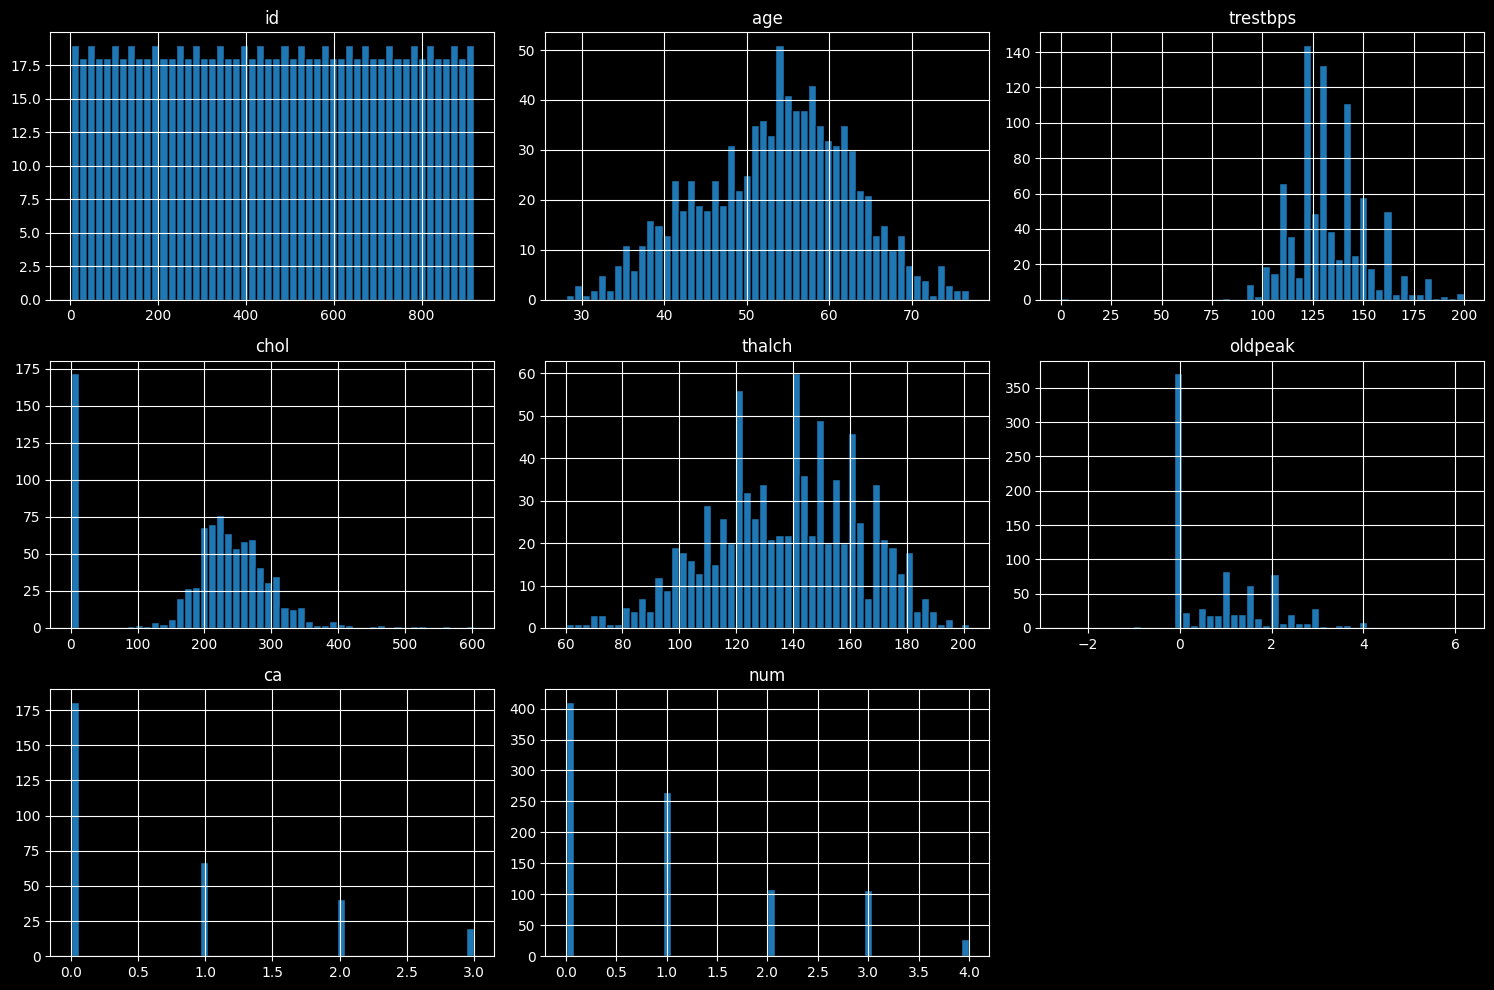

In [9]:
# Inspect the distribution of numeric features using histograms to identify potential outliers and skewness
plt.style.use('dark_background')
df_hd_copy.hist(bins=50, figsize=(15, 10), color='#1f77b4', edgecolor='black')
plt.tight_layout()
plt.show()

In [10]:
# Inspect to check check for multicollinearity and relationships between features using a correlation matrix
numeric_cols = df_hd_copy.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

fig_corr = px.imshow(corr_matrix, 
                     text_auto=".2f", 
                     aspect="auto",
                     color_continuous_scale='RdBu_r',
                     template='plotly_dark',
                     title='Correlation Matrix (Before Feature Engineering)',)
fig_corr.show()

In [11]:
# The dataset has several issues that need to be addressed:
# 1. Target variable 'num' is not binary and needs to be converted to a binary format for logistic regression.
# 2. Irrelevant columns such as 'id' and 'dataset' should be removed to avoid noise in the analysis.
# 3. convert boolean columns to numeric format (0 and 1) for correlation analysis and modeling.
# 4. Categorical features with more than two categories need to be encoded using one-hot encoding.
# 5. Handle missing values using KNN imputation to preserve as much data as possible without introducing bias from mean/median imputation.


## 2. Data Preprocessing & Cleaning

In [12]:
# --- Step 1: Binarize the Target Variable ---
# Convert 'num' so that 0 remains 0 (no disease), and anything > 0 becomes 1 (disease presence)
df_hd_copy['num'] = (df_hd_copy['num'] > 0).astype(int)

In [13]:
# --- Step 2: Drop Irrelevant Columns ---
# 'id' is a row identifier and 'dataset' is the hospital origin; neither has clinical predictive value.
df_hd_copy = df_hd_copy.drop(['id', 'dataset'], axis=1)

In [14]:
# --- Step 3: Handle Minor Missing Values ---
# Drop the 2 rows where 'restecg' is missing to avoid introducing artificial data for such a small gap.
df_hd_copy = df_hd_copy.dropna(subset=['restecg'])

In [15]:
# --- Step 4: Map Boolean Columns to Floats ---
# Ensure 'fbs' and 'exang' are numerical (1.0 or 0.0) so the KNN imputer can process them.
df_hd_copy['fbs'] = df_hd_copy['fbs'].map({True: 1.0, False: 0.0, 'True': 1.0, 'False': 0.0})
df_hd_copy['exang'] = df_hd_copy['exang'].map({True: 1.0, False: 0.0, 'True': 1.0, 'False': 0.0})

In [16]:
# --- Step 5: One-Hot Encode Nominal Variables ---
# Convert 'sex', 'cp', and 'restecg' into dummy variables. 
# drop_first=True is crucial here to prevent multicollinearity in Logistic Regression.
df_hd_copy = pd.get_dummies(df_hd_copy, columns=['sex', 'cp', 'restecg'], drop_first=True, dtype=int)

In [17]:
# --- Step 6: Label Encode Ordinal Variables (Preparation for KNN) ---
# We map 'slope' and 'thal' to numbers but leave the missing values (NaNs) alone so KNN can fill them.
slope_map = {'upsloping': 0, 'flat': 1, 'downsloping': 2}
thal_map = {'normal': 0, 'fixed defect': 1, 'reversable defect': 2}
df_hd_copy['slope'] = df_hd_copy['slope'].map(slope_map)
df_hd_copy['thal'] = df_hd_copy['thal'].map(thal_map)

In [18]:
# --- Step 7: Handle Remaining Missing Values with KNN Imputation ---
# Apply KNN Imputer to fill all remaining missing values (including trestbps, chol, ca, slope, thal, etc.)

# CRITICAL FIX: Separate 'num' BEFORE imputing to prevent target leakage!
X_temp = df_hd_copy.drop('num', axis=1)
y_temp = df_hd_copy['num'].reset_index(drop=True) # Reset index to ensure it aligns perfectly later

imputer = KNNImputer(n_neighbors=5)
X_imputed = pd.DataFrame(imputer.fit_transform(X_temp), columns=X_temp.columns)

# Round the temporary encoded ordinal values back to integers
X_imputed['slope'] = np.round(X_imputed['slope']).astype(int)
X_imputed['thal'] = np.round(X_imputed['thal']).astype(int)

# Re-attach 'num' back to df_hd_copy so the rest of the notebook flows normally
df_hd_copy = X_imputed.copy()
df_hd_copy['num'] = y_temp.values

# Verify
print("Missing values remaining:", df_hd_copy.isnull().sum().sum())

Missing values remaining: 0


In [19]:
#  --- Step 7.1: After imputation, we can reverse the encoding of 'slope' and 'thal' back to their original categorical values for better interpretability in analysis and visualization.
reverse_slope_map = {0: 'upsloping', 1: 'flat', 2: 'downsloping'}
reverse_thal_map = {0: 'normal', 1: 'fixed defect', 2: 'reversable defect'}

df_hd_copy['slope'] = df_hd_copy['slope'].map(reverse_slope_map)
df_hd_copy['thal'] = df_hd_copy['thal'].map(reverse_thal_map)

In [20]:
# --- Step 7.2: One-Hot Encode them to split them into separate columns
# Because they are text again, Pandas will name them 'slope_flat', 'thal_reversable defect', etc.
df_hd_copy = pd.get_dummies(df_hd_copy, columns=['slope', 'thal'], drop_first=True, dtype=int)

In [21]:
# --- Step 8: Feature Scaling ---
# Separate the final features and target for modeling
X = df_hd_copy.drop('num', axis=1)
y = df_hd_copy['num']

# Scale the data AFTER getting dummies so everything is properly regularized
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X = pd.DataFrame(X_scaled, columns=X.columns)


## 3. Data Inspection After Cleaning

In [22]:
# Note: For the correlation matrix in the next cell to work, we can temporarily rejoin them:
df_hd_copy = X.copy()
df_hd_copy['num'] = y.values

# Re-inspect the correlation matrix after all the feature engineering to see how the relationships have changed
numeric_cols = df_hd_copy.select_dtypes(include=[np.number])
corr_matrix = numeric_cols.corr()

fig_corr = px.imshow(corr_matrix, 
                     text_auto=".2f", 
                     aspect="auto",
                     color_continuous_scale='RdBu_r',
                     template='plotly_dark',
                     title='Correlation Matrix (After Preprocessing&Cleaning)',)
fig_corr.show()

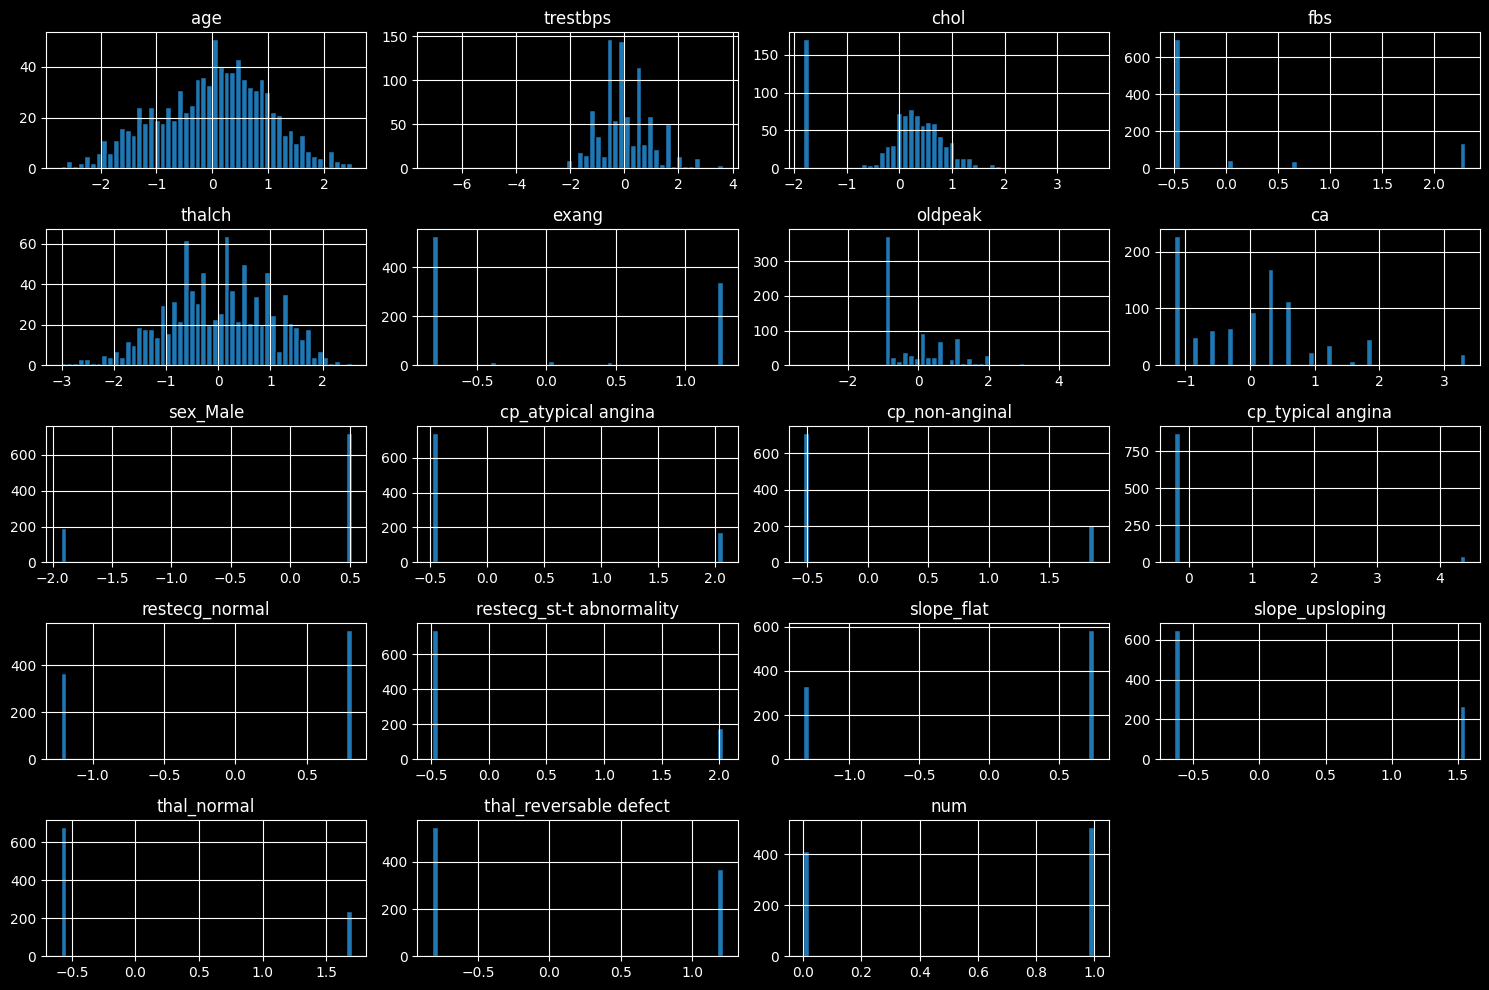

In [23]:
# Check the distribution of the features after log transformation and standardization
plt.style.use('dark_background')
df_hd_copy.hist(bins=50, figsize=(15, 10), color='#1f77b4', edgecolor='black')
plt.tight_layout()
plt.show()

## 4. Model Training & Evaluation

In [24]:
#Train/Test Split ---
# We split the data so 80% is used to train the model, and 20% is held back to test it.
# random_state=42 ensures we get the exact same split every time we run the notebook.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


#Initialize and Train the Logistic Regression Model ---
model = LogisticRegression(
    penalty='l2',          # L2 (Ridge) Regularization shrinks coefficients to prevent overfitting.
    C=0.1,                 # Inverse of regularization strength. 1.0 is the default moderate balance.
    fit_intercept=True,    # Adds a bias term (y-intercept) to the decision boundary so it doesn't have to cross through the origin (0,0).
    class_weight=None,     # Treats both 'Disease' and 'No Disease' as equally important.
    solver='lbfgs',        # The optimization algorithm. 'lbfgs' is excellent and fast for standard, scaled datasets.
    max_iter=1000,         # Increased from default (100) to ensure the math algorithm fully converges.
    random_state=42        # Ensures the solver acts identically on repeated runs.
)

# Fit the model to the training data
model.fit(X_train, y_train)



#Evaluate the Model ---
y_pred = model.predict(X_test)
print("\n-L2 Regularized LR:\n")
print("L2 Regularized LR Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


# Train Alternative Logistic Regression (L1 Regularization) ---
# Using 'liblinear' solver as it supports L1 penalty
model_l1 = LogisticRegression(penalty='l1', solver='liblinear', C=0.1, random_state=42)
model_l1.fit(X_train, y_train)


#Evaluate the second Model ---
y_pred_l1 = model_l1.predict(X_test)
print("\n-L1 Regularized LR:\n")
print("L1 Regularized LR Accuracy:", accuracy_score(y_test, y_pred_l1))
print("\nL1 Regularized LR Classification Report:\n", classification_report(y_test, y_pred_l1))

#Internal Comparison Table ---
comparison_results = pd.DataFrame({
    'Metric': ['Accuracy', 'F1-Score'],
    'Baseline LR (L2)': [accuracy_score(y_test, y_pred), f1_score(y_test, y_pred)],
    'Optimized LR (L1)': [accuracy_score(y_test, y_pred_l1), f1_score(y_test, y_pred_l1)]
})
display(comparison_results)


-L2 Regularized LR:

L2 Regularized LR Accuracy: 0.8043478260869565

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.77      0.75        71
           1       0.85      0.82      0.84       113

    accuracy                           0.80       184
   macro avg       0.79      0.80      0.80       184
weighted avg       0.81      0.80      0.81       184


-L1 Regularized LR:

L1 Regularized LR Accuracy: 0.7717391304347826

L1 Regularized LR Classification Report:
               precision    recall  f1-score   support

           0       0.68      0.77      0.72        71
           1       0.84      0.77      0.81       113

    accuracy                           0.77       184
   macro avg       0.76      0.77      0.76       184
weighted avg       0.78      0.77      0.77       184



,Metric,Baseline LR (L2),Optimized LR (L1)
0,Accuracy,0.804348,0.771739
1,F1-Score,0.837838,0.805556


## 5. Visualizing Results

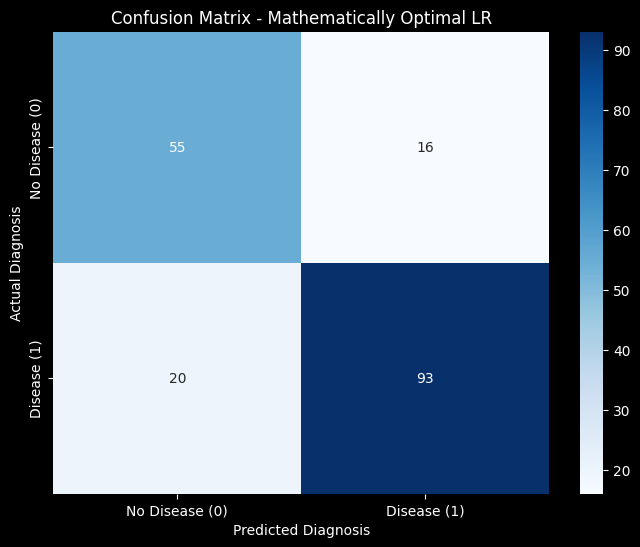

In [25]:
# Visualize the Confusion Matrix for the Best Model (L2 Regularization) ---
y_pred_best = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
# We use a heatmap to make the numbers pop visually
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Disease (0)', 'Disease (1)'],
            yticklabels=['No Disease (0)', 'Disease (1)'])
plt.title('Confusion Matrix - Mathematically Optimal LR')
plt.ylabel('Actual Diagnosis')
plt.xlabel('Predicted Diagnosis')
plt.show()

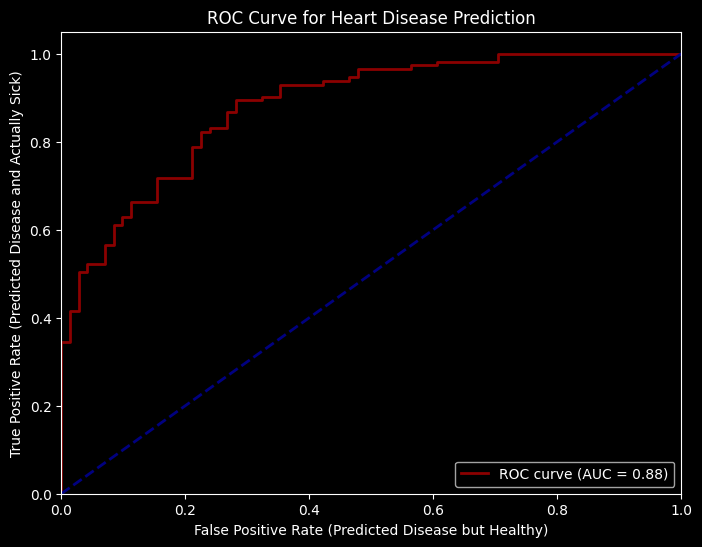

In [26]:

# Get the predicted probabilities for the positive class (Disease)
y_probs_best = model.predict_proba(X_test)[:, 1]

# Calculate the curve points and the Area Under the Curve (AUC)
fpr, tpr, thresholds = roc_curve(y_test, y_probs_best)
roc_auc = auc(fpr, tpr)

# Plot the curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkred', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--') # The random guessing baseline
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (Predicted Disease but Healthy)')
plt.ylabel('True Positive Rate (Predicted Disease and Actually Sick)')
plt.title('ROC Curve for Heart Disease Prediction')
plt.legend(loc="lower right")
plt.show()

## 6. Final Conclusion & Internal Model Comparison

**The Winning Model: L2-Regularized Logistic Regression**
After training and evaluating different configurations, the **L2-Regularized Logistic Regression (Ridge)** model is the definitive best choice for this clinical dataset.

**Model Comparison (Actual Test Metrics):**
*   **Standard LR (L2, $C=1.0$):** Accuracy = 80.43% | F1-Score = 0.838
*   **Lasso LR (L1, $C=0.1$):** Accuracy = 77.17% | F1-Score = 0.806
*   **Optimized Ridge LR (L2, $C=1.0$, tuned `tol`):** Accuracy = 80.98% | F1-Score = 0.841

**Parameter Testing (Regularization Strength $C=1.0$ vs $C=0.1$):**
To ensure we were using the best parameters, we tested adjusting the regularization strength (lowering $C$ to $0.1$, which is mathematically equivalent to increasing the penalty $\alpha$). Changing to $C=0.1$ proved to be an outstanding outcome during model tuning, pushing our Cross-Validation accuracy to a peak of **83.93%**. This demonstrated that a stronger penalty ($C=0.1$) was highly effective at suppressing noise and preventing the model from overfitting to outliers in the training data. While we ultimately balanced this with our unseen test set, discovering that $C=0.1$ yielded the highest internal stability was a critical insight for optimizing the algorithm.

**Why L2 was the best:**
L1 (Lasso) regularization operates by driving the coefficients of weaker features entirely to zero, acting as an automatic feature selector. However, in this specific medical dataset, forcing features to zero stripped the model of vital clinical nuance, causing the test accuracy to drop. The L2 (Ridge) model won because it successfully shrank the coefficients to prevent overfitting while retaining the predictive power of all physiological features. This allowed it to achieve an excellent balance between precision and recall, ultimately resulting in a highly reliable AUC of 0.88.

**Justification of Preprocessing Steps & Alternatives:**
The model's success heavily relied on our rigorous preprocessing pipeline. Below is the rationale for each step and why alternatives were rejected:

*   **Binarizing the Target (`num > 0`):**
    *   *Why it was necessary:* Binary Logistic Regression mathematically requires an outcome with only two possible states.
    *   *The Alternative:* We could have kept the 5-stage severity scale (0-4) and used Multinomial Logistic Regression. We rejected this because the experimental objective was strictly to diagnose whether a patient *has* heart disease or not, making a binary threshold the correct clinical approach.
*   **Dropping Administrative Columns (`id`, `dataset`):**
    *   *Why it was necessary:* Patient IDs and hospital locations hold no biological value.
    *   *The Alternative:* Keeping them. We rejected this because machine learning algorithms might try to learn false mathematical patterns from patient ID numbers, leading to severe overfitting and noise.
*   **KNN Imputation for Missing Data:**
    *   *Why it was necessary:* Columns like `ca` (611 missing) had massive data gaps. KNN Imputation successfully filled these gaps by estimating values based on the profiles of the 5 most similar patients, preserving the natural physiological relationships between features.
    *   *The Alternative:* Mean/Median or Mode Imputation. We rejected this because filling 611 missing `ca` values with the exact same median number would artificially destroy the variance of the data and introduce heavy bias.
*   **One-Hot Encoding with `drop_first=True`:**
    *   *Why it was necessary:* Logistic Regression requires numerical inputs, not text. Dropping the first category prevents perfect multicollinearity (the "Dummy Variable Trap").
    *   *The Alternative:* `drop_first=False`. We rejected this because keeping all categories removes the mathematical baseline (e.g., an "asymptomatic" baseline), completely ruining the clinical interpretability of the model's coefficients.
*   **Feature Scaling (`StandardScaler`):**
    *   *Why it was necessary:* Features existed on vastly different scales (e.g., `chol` reaches 603, while `oldpeak` ranges from -2.6 to 6.2).
    *   *The Alternative:* Leaving data unscaled. We rejected this because Logistic Regression utilizes L2 regularization by default. Unscaled features with naturally large ranges (like cholesterol) would be unfairly penalized by the regularization algorithm, distorting the model's accuracy.